# Topic 4 (Part 1): Train, Test & Validation Sets, Vanishing & Exploding Gradient
## Measuring Real Performance, and When Backpropagation Breaks Down

> **Goal:** Understand why we split data into train/validation/test sets, how to spot overfitting, and why very deep networks can fail to train at all.

---
## 1. Quick Recap

Last session we learned **backpropagation** — the chain rule applied layer by layer to compute the gradient of the loss with respect to every weight. Today we look at two things that come right after: how do we know the network actually *learned* (rather than memorized), and what happens to that chain of gradients when the network gets deep?

---
## 2. The Train / Validation / Test Split

We split our data three ways: **train** (used to actually update weights), **validation** (used to check progress and tune choices during training), and **test** (touched only once, at the very end, for an honest final score).

Total examples : 1000
Training set   : 700 examples (70%)
Validation set : 150 examples (15%)
Test set       : 150 examples (15%)


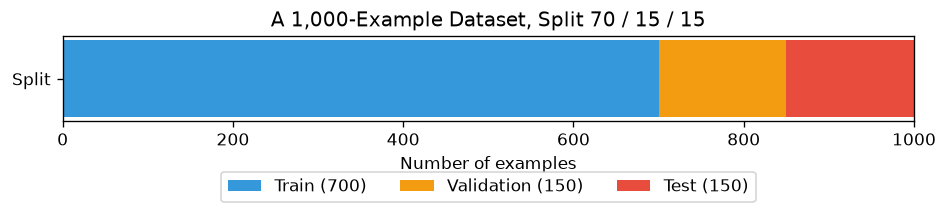


The model NEVER trains on the validation or test sets.
The test set is looked at exactly once, after all training and tuning is finished.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Simulate splitting 1,000 labeled examples the standard 70 / 15 / 15 way
n_total = 1000
np.random.seed(42)
indices = np.random.permutation(n_total)  # a shuffled list of 0..999 -- slicing by position now means "random examples"

train_frac, val_frac = 0.70, 0.15
n_train = int(n_total * train_frac)  # 700
n_val = int(n_total * val_frac)      # 150
n_test = n_total - n_train - n_val   # whatever's left over -> 150

# Slice the SHUFFLED indices into three back-to-back, non-overlapping chunks.
# Because `indices` was shuffled first, each chunk is a random sample of the data --
# and because the three slices cover positions 0..999 with no gaps or repeats, every
# example ends up in EXACTLY ONE of the three sets.
train_idx = indices[:n_train]                 # positions   0 .. 699  -> first 700 shuffled examples
val_idx = indices[n_train:n_train + n_val]     # positions 700 .. 849  -> next 150 shuffled examples
test_idx = indices[n_train + n_val:]           # positions 850 .. 999  -> the remaining 150 examples

print(f"Total examples : {n_total}")
print(f"Training set   : {len(train_idx)} examples ({len(train_idx)/n_total:.0%})")
print(f"Validation set : {len(val_idx)} examples ({len(val_idx)/n_total:.0%})")
print(f"Test set       : {len(test_idx)} examples ({len(test_idx)/n_total:.0%})")

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.barh(['Split'], [len(train_idx)], color='#3498db', label=f'Train ({len(train_idx)})')
ax.barh(['Split'], [len(val_idx)], left=[len(train_idx)], color='#f39c12', label=f'Validation ({len(val_idx)})')
ax.barh(['Split'], [len(test_idx)], left=[len(train_idx) + len(val_idx)], color='#e74c3c', label=f'Test ({len(test_idx)})')
ax.set_xlim(0, n_total)
ax.set_xlabel('Number of examples')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5), ncol=3)
ax.set_title('A 1,000-Example Dataset, Split 70 / 15 / 15')
plt.tight_layout()
plt.show()

print("\nThe model NEVER trains on the validation or test sets.")
print("The test set is looked at exactly once, after all training and tuning is finished.")

---
## 3. Underfitting vs. Overfitting

As a model gets more complex, training error keeps dropping — but validation error tells a different story. Let's see this happen with real numbers: we'll fit polynomials of increasing degree to a small, noisy dataset, and watch what happens to training vs. validation error.

Degree  1:  Training MSE = 0.1801   Validation MSE = 0.1721
Degree  3:  Training MSE = 0.0242   Validation MSE = 0.0283
Degree  5:  Training MSE = 0.0218   Validation MSE = 0.0351
Degree  8:  Training MSE = 0.0162   Validation MSE = 0.0430
Degree 10:  Training MSE = 0.0162   Validation MSE = 0.0412
Degree 12:  Training MSE = 0.0096   Validation MSE = 1.6365
Degree 14:  Training MSE = 0.0000   Validation MSE = 51698847.2865


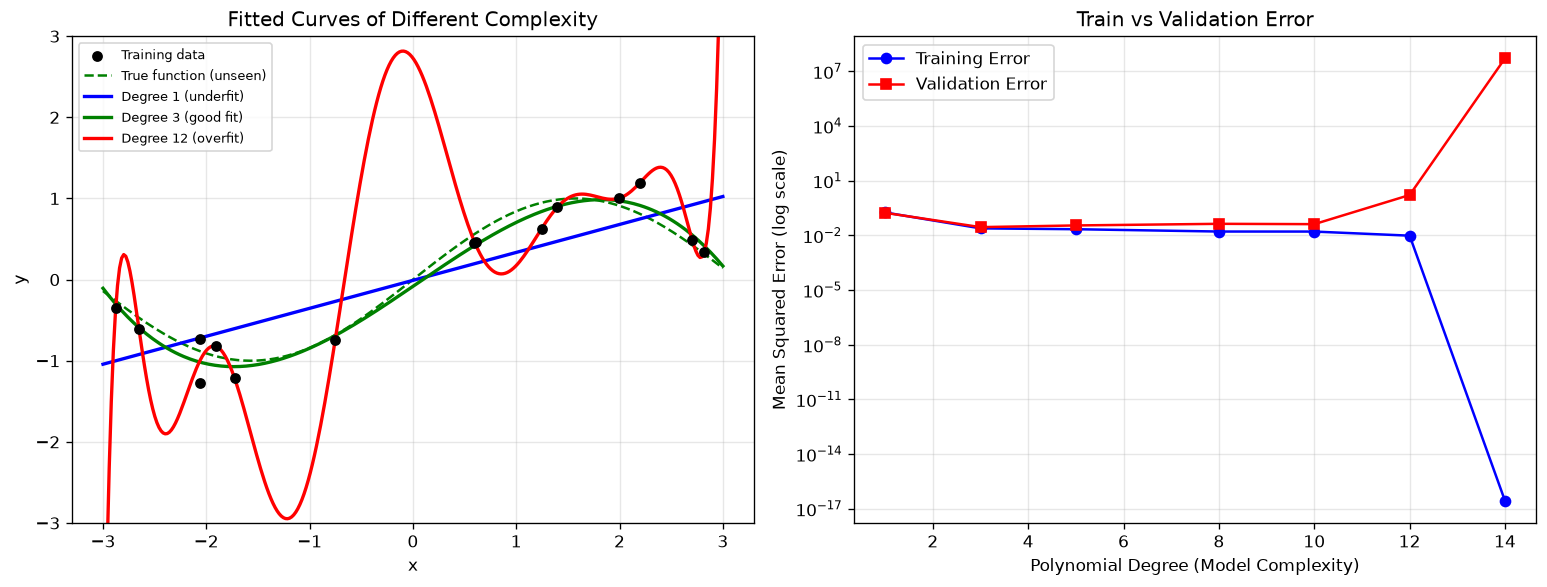


Best validation performance: degree 3
Notice: training error keeps shrinking all the way to degree 14, but validation
error bottoms out around degree 3 and then EXPLODES -- that's overfitting.


In [2]:
# A small noisy training set, and a larger validation set drawn from the same distribution
np.random.seed(42)

def true_fn(x):
    return np.sin(x)

n_train = 15
X_train = np.sort(np.random.uniform(-3, 3, n_train))
y_train = true_fn(X_train) + np.random.normal(0, 0.15, n_train)

n_val = 100
X_val = np.sort(np.random.uniform(-3, 3, n_val))
y_val = true_fn(X_val) + np.random.normal(0, 0.15, n_val)

degrees = [1, 3, 5, 8, 10, 12, 14]
train_errors, val_errors = [], []

for deg in degrees:
    coeffs = np.polyfit(X_train, y_train, deg)
    train_pred = np.polyval(coeffs, X_train)
    val_pred = np.polyval(coeffs, X_val)
    train_errors.append(np.mean((train_pred - y_train) ** 2))
    val_errors.append(np.mean((val_pred - y_val) ** 2))
    print(f"Degree {deg:2d}:  Training MSE = {train_errors[-1]:.4f}   Validation MSE = {val_errors[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: a few example fitted curves
x_smooth = np.linspace(-3, 3, 300)
axes[0].scatter(X_train, y_train, color='black', s=30, zorder=5, label='Training data')
axes[0].plot(x_smooth, true_fn(x_smooth), 'g--', linewidth=1.5, label='True function (unseen)')
for deg, color, label in [(1, 'blue', 'Degree 1 (underfit)'), (3, 'green', 'Degree 3 (good fit)'), (12, 'red', 'Degree 12 (overfit)')]:
    coeffs = np.polyfit(X_train, y_train, deg)
    axes[0].plot(x_smooth, np.polyval(coeffs, x_smooth), color=color, linewidth=2, label=label)
axes[0].set_ylim(-3, 3)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Fitted Curves of Different Complexity')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: training vs validation error as complexity increases
axes[1].plot(degrees, train_errors, 'o-', color='blue', label='Training Error')
axes[1].plot(degrees, val_errors, 's-', color='red', label='Validation Error')
axes[1].set_yscale('log')
axes[1].set_xlabel('Polynomial Degree (Model Complexity)')
axes[1].set_ylabel('Mean Squared Error (log scale)')
axes[1].set_title('Train vs Validation Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest validation performance: degree {degrees[np.argmin(val_errors)]}")
print("Notice: training error keeps shrinking all the way to degree 14, but validation")
print("error bottoms out around degree 3 and then EXPLODES -- that's overfitting.")

---
## 4. The Vanishing & Exploding Gradient Problem

Backpropagation computes gradients by **multiplying** one factor per layer (an activation derivative and a weight) via the chain rule. Multiply enough numbers smaller than 1 together, and the result shrinks toward zero. Multiply enough numbers larger than 1, and it grows toward infinity.

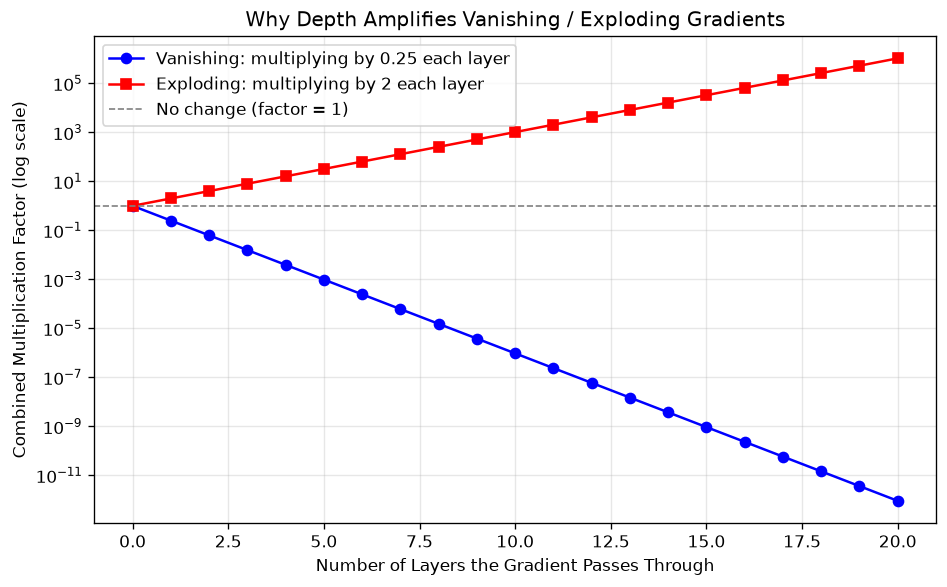

After  5 layers: 0.25^5  = 0.000977   |   2^5  = 32
After 10 layers: 0.25^10 = 9.54e-07   |   2^10 = 1024
After 20 layers: 0.25^20 = 9.09e-13   |   2^20 = 1,048,576

Even a small per-layer factor becomes extreme once it compounds across many layers.


In [3]:
# The pure arithmetic behind vanishing vs exploding gradients:
# multiplying the SAME factor once per layer, many layers in a row.
n_layers = np.arange(0, 21)

vanishing_factor = 0.25 ** n_layers   # Sigmoid's best-case derivative is 0.25
exploding_factor = 2.0 ** n_layers    # just one example of a >1 multiplier

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(n_layers, vanishing_factor, 'o-', color='blue', label='Vanishing: multiplying by 0.25 each layer')
ax.semilogy(n_layers, exploding_factor, 's-', color='red', label='Exploding: multiplying by 2 each layer')
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='No change (factor = 1)')
ax.set_xlabel('Number of Layers the Gradient Passes Through')
ax.set_ylabel('Combined Multiplication Factor (log scale)')
ax.set_title('Why Depth Amplifies Vanishing / Exploding Gradients')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"After  5 layers: 0.25^5  = {0.25**5:.6f}   |   2^5  = {2**5}")
print(f"After 10 layers: 0.25^10 = {0.25**10:.2e}   |   2^10 = {2**10}")
print(f"After 20 layers: 0.25^20 = {0.25**20:.2e}   |   2^20 = {2**20:,}")
print("\nEven a small per-layer factor becomes extreme once it compounds across many layers.")

### Does this actually happen inside a real network's backward pass?

Let's trace an actual gradient backward through a 20-layer network under three different conditions, and measure its size at every layer.

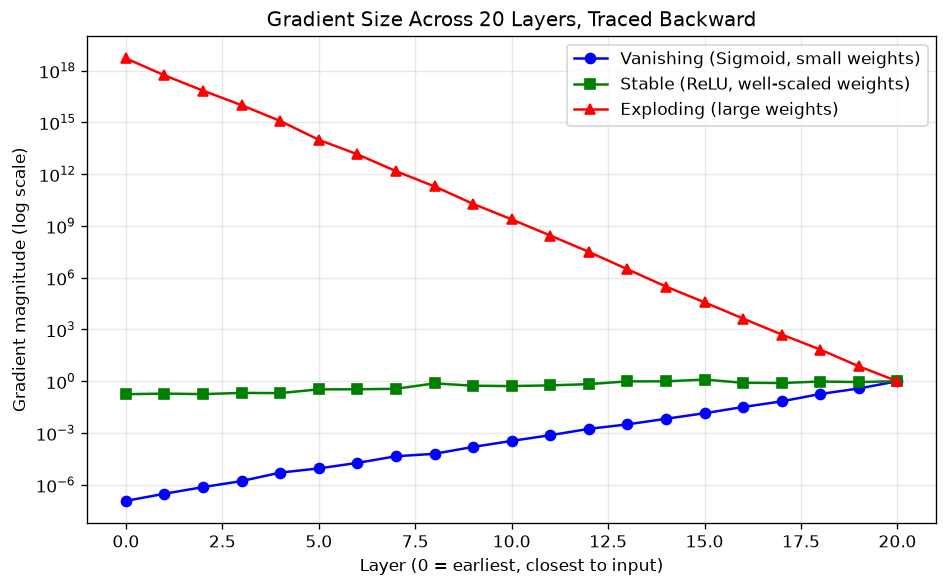

Gradient at the FIRST layer (closest to input):
  Vanishing setup: 1.17e-07
  Stable setup:    1.78e-01
  Exploding setup: 5.15e+18

The vanishing setup's first-layer gradient is effectively zero -- that layer
will barely update. The exploding setup's gradient is astronomically large --
a single update step would send its weights to nonsensical values.


In [4]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def identity(x): return x
def identity_derivative(x): return np.ones_like(x)

def gradient_trace(n_layers, layer_size, activation, activation_derivative, weight_scale, seed=0):
    """Forward through n_layers identical layers, then send a gradient of 1.0
    backward from the output and record its size at every layer."""
    rng = np.random.RandomState(seed)
    x = rng.randn(1, layer_size)
    weights = [rng.randn(layer_size, layer_size) * weight_scale for _ in range(n_layers)]

    zs = []
    a = x
    for W in weights:
        z = a.dot(W)
        a = activation(z)
        zs.append(z)

    grad = np.ones((1, layer_size))
    magnitudes = [np.mean(np.abs(grad))]
    for W, z in zip(reversed(weights), reversed(zs)):
        grad = (grad * activation_derivative(z)).dot(W.T)
        magnitudes.append(np.mean(np.abs(grad)))
    return magnitudes[::-1]  # earliest layer first

n_layers, layer_size = 20, 20
vanishing = gradient_trace(n_layers, layer_size, sigmoid, sigmoid_derivative, weight_scale=0.5)
stable    = gradient_trace(n_layers, layer_size, relu, relu_derivative, weight_scale=np.sqrt(2.0 / layer_size))
exploding = gradient_trace(n_layers, layer_size, identity, identity_derivative, weight_scale=2.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(range(len(vanishing)), vanishing, 'o-', color='blue', label='Vanishing (Sigmoid, small weights)')
ax.semilogy(range(len(stable)), stable, 's-', color='green', label='Stable (ReLU, well-scaled weights)')
ax.semilogy(range(len(exploding)), exploding, '^-', color='red', label='Exploding (large weights)')
ax.set_xlabel('Layer (0 = earliest, closest to input)')
ax.set_ylabel('Gradient magnitude (log scale)')
ax.set_title('Gradient Size Across 20 Layers, Traced Backward')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gradient at the FIRST layer (closest to input):")
print(f"  Vanishing setup: {vanishing[0]:.2e}")
print(f"  Stable setup:    {stable[0]:.2e}")
print(f"  Exploding setup: {exploding[0]:.2e}")
print("\nThe vanishing setup's first-layer gradient is effectively zero -- that layer")
print("will barely update. The exploding setup's gradient is astronomically large --")
print("a single update step would send its weights to nonsensical values.")

---
## 5. Proof: Vanishing Gradients Actually Cripple Training

A one-shot gradient trace is convincing, but let's prove the consequence directly: train a genuinely deep (6 hidden layer) network on our familiar 2-class dataset, once with Sigmoid hidden layers and once with ReLU, and watch what happens to the loss.

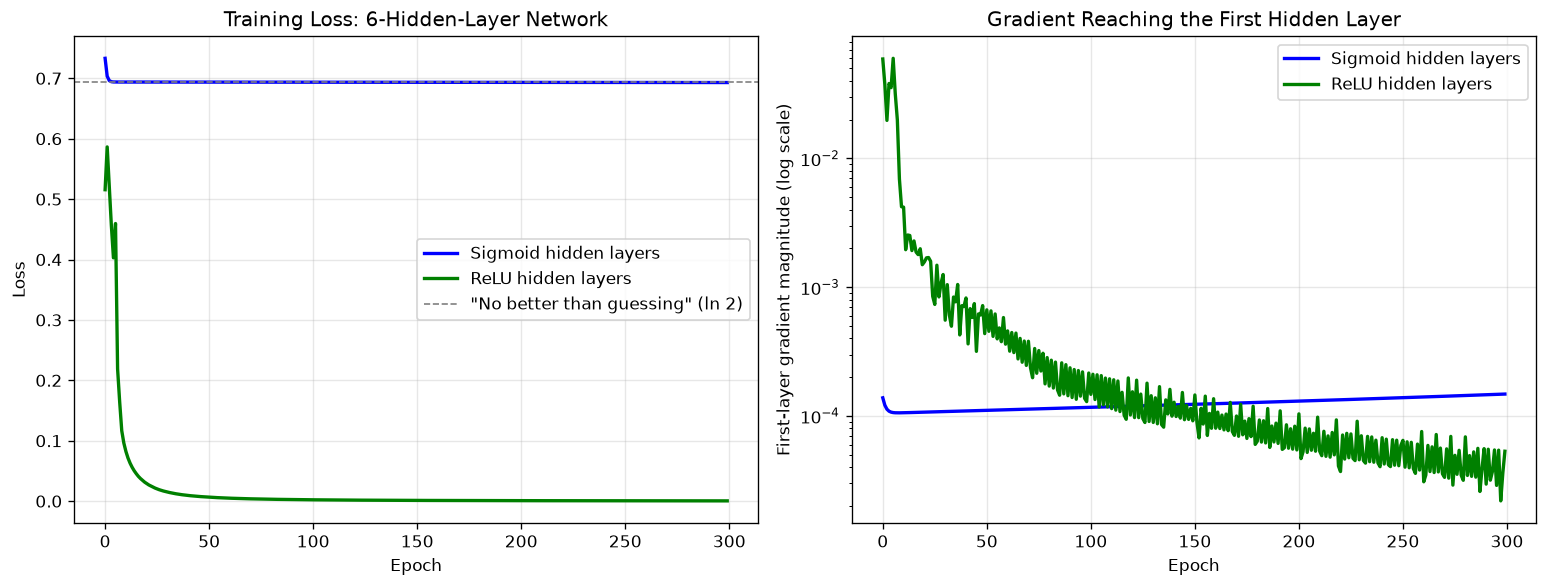

Sigmoid network: loss went from 0.7331 to 0.6930 over 300 epochs
ReLU network:    loss went from 0.5156 to 0.0005 over 300 epochs

For reference, ln(2) = 0.6931 -- the loss of a model that always predicts 50/50.

First-layer gradient magnitude at epoch 0 -- Sigmoid: 1.38e-04  |  ReLU: 5.93e-02
The Sigmoid network's loss barely moves off the 'random guessing' baseline --
its first hidden layer's gradient is thousands of times smaller than ReLU's,
so that layer essentially never updates. This is vanishing gradients in action,
not just a one-off trace, but a real network that fails to learn because of it.


In [5]:
# The same two-class dataset from previous sessions
np.random.seed(42)
n_points = 50
class_0 = np.random.randn(n_points, 2) + np.array([0, 0])
class_1 = np.random.randn(n_points, 2) + np.array([3, 3])
X = np.vstack([class_0, class_1])
y = np.array([0]*n_points + [1]*n_points).reshape(-1, 1)

def build_deep_network(n_hidden_layers, layer_size, input_size=2, output_size=1, seed=0):
    rng = np.random.RandomState(seed)
    sizes = [input_size] + [layer_size] * n_hidden_layers + [output_size]
    Ws = [rng.randn(sizes[i], sizes[i+1]) * 0.5 for i in range(len(sizes) - 1)]
    bs = [np.zeros((1, sizes[i+1])) for i in range(len(sizes) - 1)]
    return Ws, bs

def train_deep(activation, activation_derivative, n_hidden_layers, layer_size, epochs, lr, seed=0):
    """Train an n_hidden_layers-deep network (Sigmoid output, given activation for hidden
    layers) with plain gradient descent, tracking loss and the very first layer's gradient size."""
    Ws, bs = build_deep_network(n_hidden_layers, layer_size, seed=seed)
    n_layers = len(Ws)
    losses, first_layer_grad_norms = [], []

    for epoch in range(epochs):
        zs, activations = [], [X]
        a = X
        for i in range(n_layers):
            z = a.dot(Ws[i]) + bs[i]
            a = sigmoid(z) if i == n_layers - 1 else activation(z)
            zs.append(z)
            activations.append(a)
        a_out = activations[-1]

        eps = 1e-8
        loss = -np.mean(y * np.log(a_out + eps) + (1 - y) * np.log(1 - a_out + eps))
        losses.append(loss)

        dz = a_out - y
        grads_W, grads_b = [None] * n_layers, [None] * n_layers
        for i in reversed(range(n_layers)):
            grads_W[i] = activations[i].T.dot(dz) / len(X)
            grads_b[i] = np.mean(dz, axis=0, keepdims=True)
            if i == 0:
                first_layer_grad_norms.append(np.mean(np.abs(grads_W[i])))
            if i > 0:
                dz = dz.dot(Ws[i].T) * activation_derivative(zs[i-1])
        for i in range(n_layers):
            Ws[i] -= lr * grads_W[i]
            bs[i] -= lr * grads_b[i]

    return losses, first_layer_grad_norms

n_hidden_layers, layer_size, epochs, lr = 6, 10, 300, 0.5
sig_losses, sig_grads = train_deep(sigmoid, sigmoid_derivative, n_hidden_layers, layer_size, epochs, lr)
relu_losses, relu_grads = train_deep(relu, relu_derivative, n_hidden_layers, layer_size, epochs, lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(sig_losses, color='blue', linewidth=2, label='Sigmoid hidden layers')
axes[0].plot(relu_losses, color='green', linewidth=2, label='ReLU hidden layers')
axes[0].axhline(y=np.log(2), color='gray', linestyle='--', linewidth=1, label='"No better than guessing" (ln 2)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'Training Loss: {n_hidden_layers}-Hidden-Layer Network')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(sig_grads, color='blue', linewidth=2, label='Sigmoid hidden layers')
axes[1].semilogy(relu_grads, color='green', linewidth=2, label='ReLU hidden layers')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('First-layer gradient magnitude (log scale)')
axes[1].set_title('Gradient Reaching the First Hidden Layer')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sigmoid network: loss went from {sig_losses[0]:.4f} to {sig_losses[-1]:.4f} over {epochs} epochs")
print(f"ReLU network:    loss went from {relu_losses[0]:.4f} to {relu_losses[-1]:.4f} over {epochs} epochs")
print(f"\nFor reference, ln(2) = {np.log(2):.4f} -- the loss of a model that always predicts 50/50.")
print(f"\nFirst-layer gradient magnitude at epoch 0 -- Sigmoid: {sig_grads[0]:.2e}  |  ReLU: {relu_grads[0]:.2e}")
print("The Sigmoid network's loss barely moves off the 'random guessing' baseline --")
print("its first hidden layer's gradient is thousands of times smaller than ReLU's,")
print("so that layer essentially never updates. This is vanishing gradients in action,")
print("not just a one-off trace, but a real network that fails to learn because of it.")

---
## 6. Key Takeaways

### What We Learned:
1. **Train / Validation / Test split** keeps our evaluation honest — we never judge a model using data it trained on
2. **Overfitting** shows up as training error still falling while validation error rises — proven above with a real polynomial-fitting example
3. **Vanishing gradients** come from repeatedly multiplying factors smaller than 1 through the chain rule — Sigmoid/Tanh are especially prone to this
4. **Exploding gradients** come from repeatedly multiplying factors larger than 1 — large weights or unbounded activations are the usual cause
5. **Depth amplifies both problems**, since more layers means more multiplications
6. We proved this isn't just theory: a real 6-hidden-layer Sigmoid network got stuck at "random guessing" loss, while the same network with ReLU trained to near-zero loss

### The Big Picture:
> A network is only as trustworthy as its validation on unseen data, and only as trainable as the gradients that reach its earliest layers. Both the train/validation/test split and the choice of activation function/initialization exist to protect against the same failure mode: a network that looks fine on the surface but has actually failed to learn.